# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

# Load the dataset

In [2]:
file_path = "../data/public_emdat.xlsx"

df = pd.read_excel(file_path, sheet_name="EM-DAT Data")

info_df = pd.read_excel(file_path, sheet_name="EM-DAT Info")


# Data shape

In [3]:
df.shape

(17756, 47)

# Info sheet

In [4]:
info_df.head(20)

,Source:,"EM-DAT, CRED / UCLouvain, Brussels, Belgium"
0,NaN,https://www.emdat.be
1,Glossary:,https://doc.emdat.be/docs/data-structure-and-c...
2,Version:,2026-03-13
3,File creation:,"Sat, 14 Mar 2026 15:52:56 UTC"
4,Table type:,public_emdat_custom_request
5,# of records:,17756


# Basic structure and types

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17756 entries, 0 to 17755
Data columns (total 47 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   DisNo.                                     17756 non-null  str    
 1   Historic                                   17756 non-null  str    
 2   Classification Key                         17756 non-null  str    
 3   Disaster Group                             17756 non-null  str    
 4   Disaster Subgroup                          17756 non-null  str    
 5   Disaster Type                              17756 non-null  str    
 6   Disaster Subtype                           17756 non-null  str    
 7   External IDs                               4594 non-null   str    
 8   Event Name                                 4319 non-null   str    
 9   ISO                                        17756 non-null  str    
 10  Country                          

# Summary statistics

In [6]:
# df.describe(include="all").T

# Clean column names

In [7]:
df.columns = [col.strip().replace(" ", "_").replace(".", "").replace("/", "_") for col in df.columns]
df.columns.tolist()
eda_df = df.copy()

# Check missing values

In [8]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
})

missing_df

,missing_count,missing_percent
"Reconstruction_Costs,_Adjusted_('000_US$)",17716,99.774724
Reconstruction_Costs_('000_US$),17715,99.769092
AID_Contribution_('000_US$),16981,95.635278
"Insured_Damage,_Adjusted_('000_US$)",16619,93.596531
Insured_Damage_('000_US$),16609,93.540212
River_Basin,16154,90.977698
No_Homeless,15213,85.678081
Longitude,14923,84.044830
Latitude,14923,84.044830
Associated_Types,13488,75.963055


# missing values for key columns

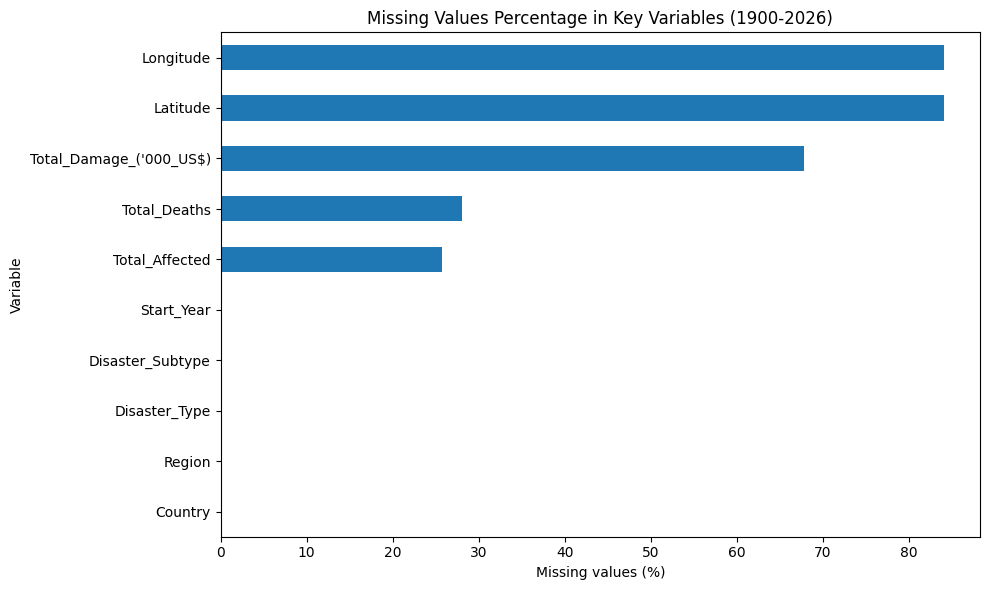

In [ ]:
year_start = 1900
year_end = 2026

selected_cols = [
    "Country",
    "Region",
    "Disaster_Type",
    "Disaster_Subtype",
    "Start_Year",
    "Total_Deaths",
    "Total_Affected",
    "Latitude",
    "Longitude",
    "Total_Damage_('000_US$)"
]

filtered_df = eda_df[
    (eda_df["Start_Year"] >= year_start) &
    (eda_df["Start_Year"] <= year_end)
].copy()

missing_pct = filtered_df[selected_cols].isnull().mean().sort_values(ascending=True) * 100

plt.figure(figsize=(10, 6))
missing_pct.plot(kind="barh")
plt.title(f"Missing Values Percentage in Key Variables ({year_start}-{year_end})")
plt.xlabel("Missing values (%)")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

# Check duplicates

In [10]:
print("Total duplicated rows:", df.duplicated().sum())

# Check duplicated disaster IDs
print("Duplicated 'DisNo.':", df["DisNo"].duplicated().sum())

Total duplicated rows: 0
Duplicated 'DisNo.': 0


# Inspect important categorical columns

In [11]:

categorical_cols = [
    "Historic",
    "Disaster_Group",
    "Disaster_Subgroup",
    "Disaster_Type",
    "Disaster_Subtype",
    "Country",
    "Subregion",
    "Region"
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print("Unique values:", df[col].nunique(dropna=True))
    display(df[col].value_counts(dropna=False).head(10))



--- Historic ---
Unique values: 2


Historic
No     10708
Yes     7048
Name: count, dtype: int64


--- Disaster_Group ---
Unique values: 1


Disaster_Group
Natural    17756
Name: count, dtype: int64


--- Disaster_Subgroup ---
Unique values: 6


...

Country
United States of America    1211
China                       1039
India                        804
Philippines                  730
Indonesia                    660
Japan                        403
Bangladesh                   372
Mexico                       313
Brazil                       301
Viet Nam                     288
Name: count, dtype: int64


--- Subregion ---
Unique values: 17


Subregion
Latin America and the Caribbean    3051
Sub-Saharan Africa                 2926
Southern Asia                      2246
South-eastern Asia                 2209
Eastern Asia                       1932
Northern America                   1379
Southern Europe                     736
Eastern Europe                      657
Western Europe                      573
Western Asia                        563
Name: count, dtype: int64


--- Region ---
Unique values: 5


Region
Asia        7105
Americas    4430
Africa      3272
Europe      2228
Oceania      721
Name: count, dtype: int64

# Explore year coverage

In [12]:

print("Start Year range:", eda_df["Start_Year"].min(), "to", eda_df["Start_Year"].max())
print("End Year range:", eda_df["End_Year"].min(), "to", eda_df["End_Year"].max())


Start Year range: 1900 to 2026
End Year range: 1900 to 2026


# Number of disasters recorded over time

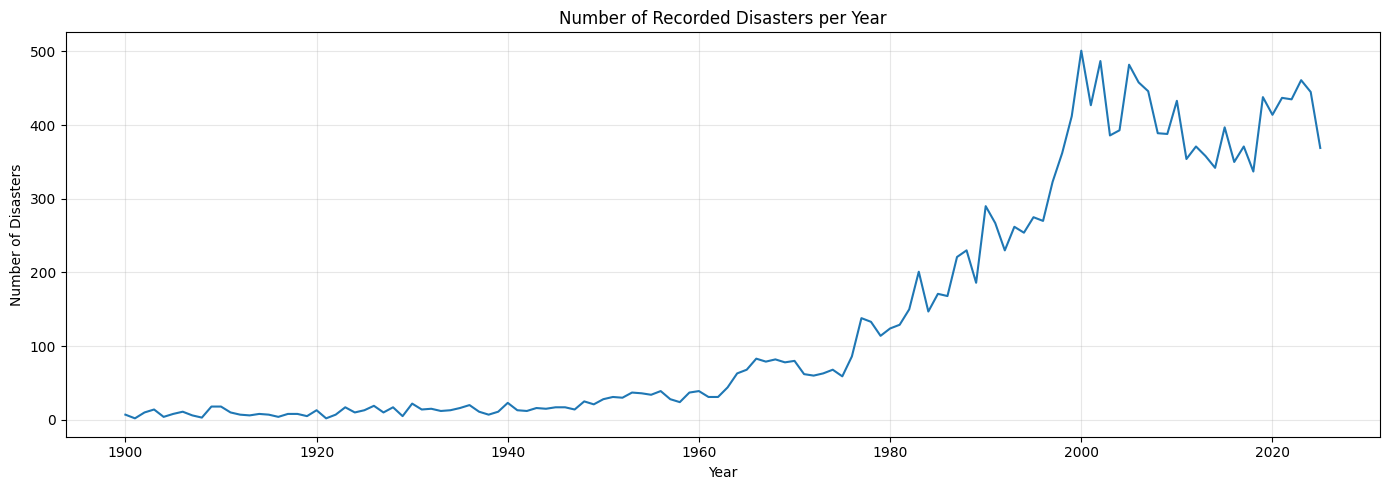

In [13]:
time_df = eda_df[eda_df["Start_Year"] < 2026].copy()
events_per_year = time_df["Start_Year"].value_counts().sort_index()

plt.figure(figsize=(14, 5))
events_per_year.plot()
plt.title("Number of Recorded Disasters per Year")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Top disaster subgroups

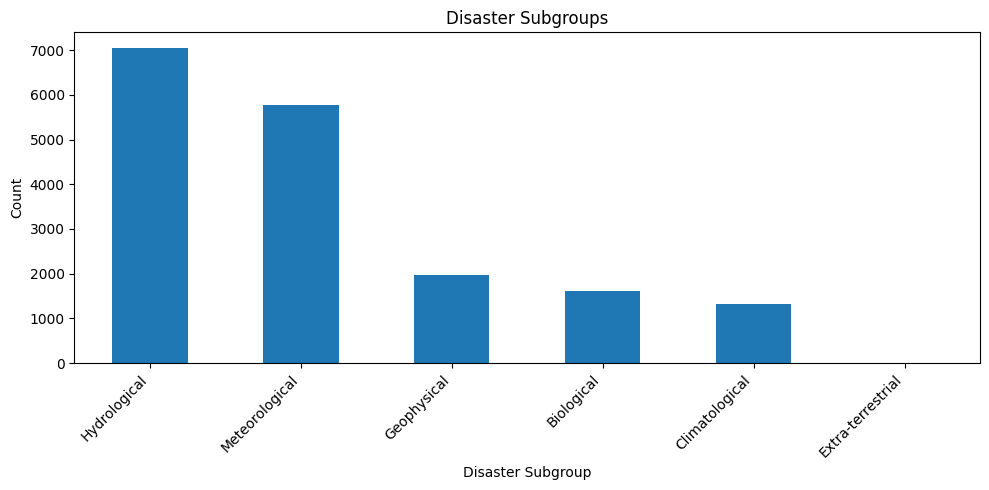

In [14]:

plt.figure(figsize=(10, 5))
eda_df["Disaster_Subgroup"].value_counts().plot(kind="bar")
plt.title("Disaster Subgroups")
plt.xlabel("Disaster Subgroup")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Top disaster types

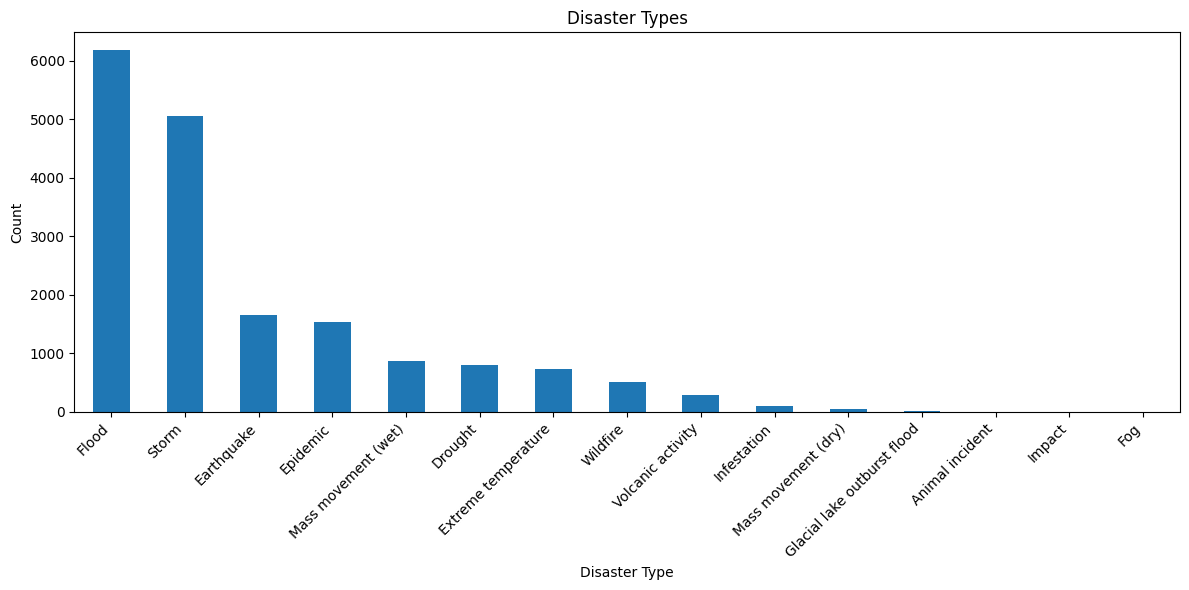

In [15]:

plt.figure(figsize=(12, 6))
eda_df["Disaster_Type"].value_counts().sort_values(ascending=False).plot(kind="bar")
plt.title("Disaster Types")
plt.xlabel("Disaster Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Top disaster subtypes

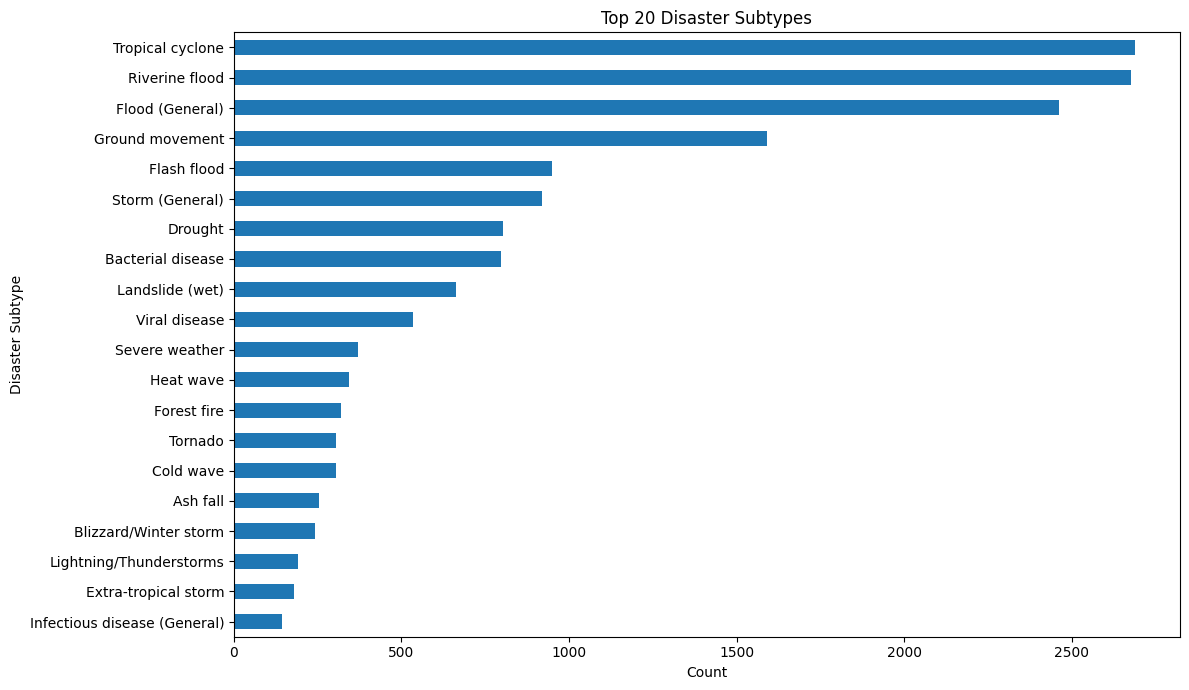

In [16]:

top_subtypes = eda_df["Disaster_Subtype"].value_counts().head(20)

plt.figure(figsize=(12, 7))
top_subtypes.sort_values().plot(kind="barh")
plt.title("Top 20 Disaster Subtypes")
plt.xlabel("Count")
plt.ylabel("Disaster Subtype")
plt.tight_layout()
plt.show()


# Countries with the most recorded disasters

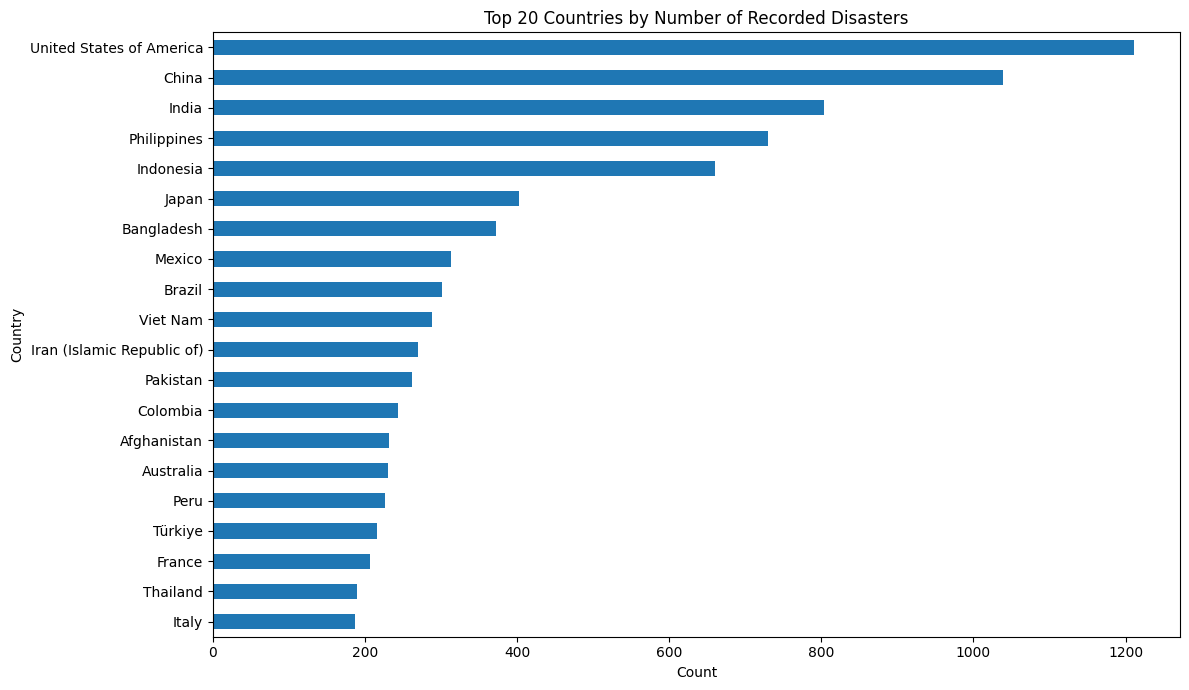

In [17]:

top_countries = eda_df["Country"].value_counts().head(20)

plt.figure(figsize=(12, 7))
top_countries.sort_values().plot(kind="barh")
plt.title("Top 20 Countries by Number of Recorded Disasters")
plt.xlabel("Count")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


# Events by region

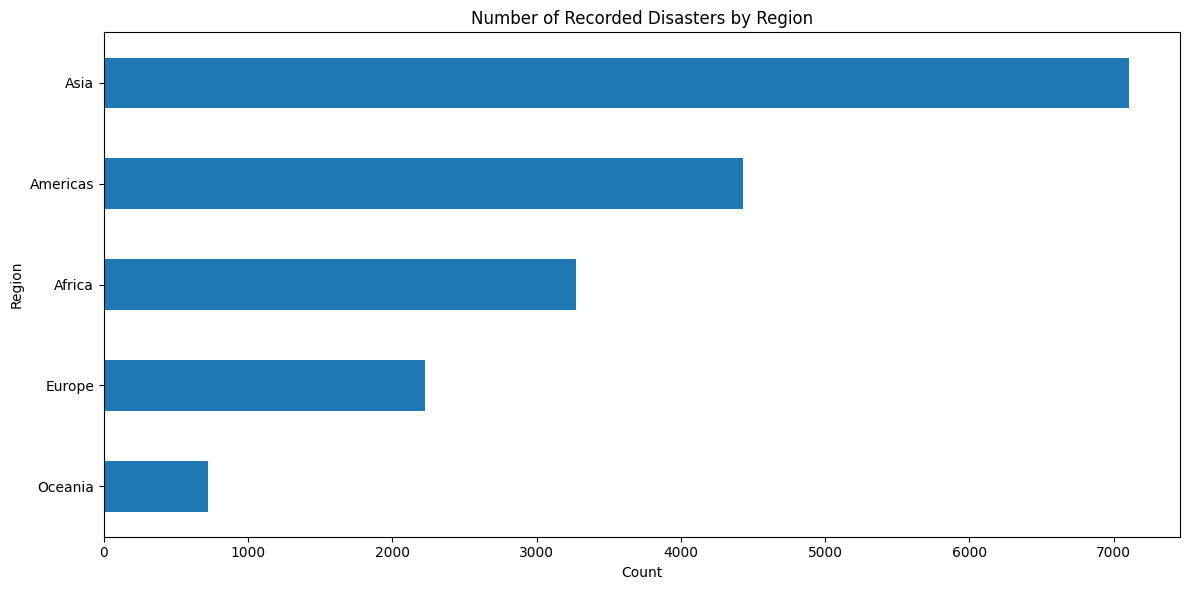

In [18]:

plt.figure(figsize=(12, 6))
eda_df["Region"].value_counts().sort_values().plot(kind="barh")
plt.title("Number of Recorded Disasters by Region")
plt.xlabel("Count")
plt.ylabel("Region")
plt.tight_layout()
plt.show()


# Build a proper start date

In [19]:

eda_df["Start_Month"] = pd.to_numeric(eda_df["Start_Month"], errors="coerce")
eda_df["Start_Day"] = pd.to_numeric(eda_df["Start_Day"], errors="coerce")
eda_df["Start_Year"] = pd.to_numeric(eda_df["Start_Year"], errors="coerce")

eda_df["Start_Month_filled"] = eda_df["Start_Month"].fillna(1)
eda_df["Start_Day_filled"] = eda_df["Start_Day"].fillna(1)

eda_df["Start_Date"] = pd.to_datetime(
    dict(
        year=eda_df["Start_Year"],
        month=eda_df["Start_Month_filled"],
        day=eda_df["Start_Day_filled"]
    ),
    errors="coerce"
)

eda_df[["Start_Year", "Start_Month", "Start_Day", "Start_Date"]].head()


,Start_Year,Start_Month,Start_Day,Start_Date
0,2026,2.0,27.0,2026-02-27
1,2026,3.0,3.0,2026-03-03
2,2026,2.0,24.0,2026-02-24
3,2026,2.0,23.0,2026-02-23
4,2026,2.0,21.0,2026-02-21


# Monthly seasonality

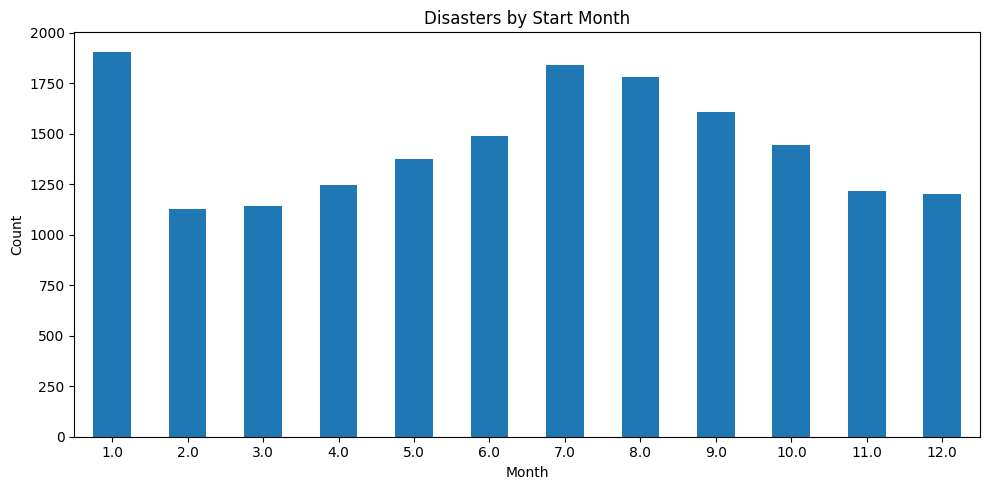

In [20]:

monthly_counts = eda_df["Start_Month"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
monthly_counts.plot(kind="bar")
plt.title("Disasters by Start Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# Human impact variables overview

In [21]:
impact_cols = [
    "Total_Deaths",
    "No_Injured",
    "No_Affected",
    "No_Homeless",
    "Total_Affected"
]

print("Summary statistics:")
display(eda_df[impact_cols].describe().T)

print("\nMissing values percentage:")
impact_missing = eda_df[impact_cols].isnull().mean().sort_values(ascending=False) * 100
display(impact_missing)


Summary statistics:


,count,mean,std,min,25%,50%,75%,max
Total_Deaths,12777.0,2566.974485,6.484804e+04,1.0,5.0,18.0,60.0,3700000.0
No_Injured,4654.0,2488.476364,3.182414e+04,1.0,12.0,50.0,200.0,1800000.0
No_Affected,10602.0,830139.147048,8.036395e+06,1.0,1300.0,10000.0,93076.5,330000000.0
No_Homeless,2543.0,71596.490366,5.121321e+05,3.0,500.0,3000.0,16493.5,15850000.0
Total_Affected,13193.0,681784.770788,7.278962e+06,1.0,700.0,6000.0,60000.0,330000000.0



Missing values percentage:


No_Homeless       85.678081
No_Injured        73.789142
No_Affected       40.290606
Total_Deaths      28.041226
Total_Affected    25.698355
dtype: float64

# Financial variables overview

In [22]:

financial_cols = [
    "AID_Contribution_('000_US$)",
    "Reconstruction_Costs_('000_US$)",
    "Reconstruction_Costs,_Adjusted_('000_US$)",
    "Insured_Damage_('000_US$)",
    "Insured_Damage,_Adjusted_('000_US$)",
    "Total_Damage_('000_US$)",
    "Total_Damage,_Adjusted_('000_US$)"
]

existing_financial_cols = [col for col in financial_cols if col in eda_df.columns]

print("Summary statistics:")
display(eda_df[existing_financial_cols].describe().T)

print("\nMissing values percentage:")
financial_missing = eda_df[existing_financial_cols].isnull().mean().sort_values(ascending=False) * 100
display(financial_missing)


Summary statistics:


,count,mean,std,min,25%,50%,75%,max
AID_Contribution_('000_US$),775.0,2.005924e+04,1.691388e+05,1.0,174.5,721.0,3648.50,3518530.0
Reconstruction_Costs_('000_US$),41.0,5.595323e+06,1.604484e+07,84.0,65000.0,538000.0,5200000.00,100000000.0
"Reconstruction_Costs,_Adjusted_('000_US$)",40.0,7.100618e+06,1.789556e+07,135.0,102167.5,553402.0,5548459.75,102949511.0
Insured_Damage_('000_US$),1147.0,1.001247e+06,3.931998e+06,34.0,54500.0,186000.0,585000.00,60000000.0
"Insured_Damage,_Adjusted_('000_US$)",1137.0,1.380909e+06,5.102017e+06,49.0,99820.0,287580.0,883442.00,96375512.0
Total_Damage_('000_US$),5715.0,8.445102e+05,5.028629e+06,2.0,10000.0,70000.0,375000.00,210000000.0
"Total_Damage,_Adjusted_('000_US$)",5637.0,1.361003e+06,7.392502e+06,3.0,20586.0,138555.0,690802.00,292855483.0



Missing values percentage:


Reconstruction_Costs,_Adjusted_('000_US$)    99.774724
Reconstruction_Costs_('000_US$)              99.769092
AID_Contribution_('000_US$)                  95.635278
Insured_Damage,_Adjusted_('000_US$)          93.596531
Insured_Damage_('000_US$)                    93.540212
Total_Damage,_Adjusted_('000_US$)            68.252985
Total_Damage_('000_US$)                      67.813697
dtype: float64

# Compare disaster types by total deaths

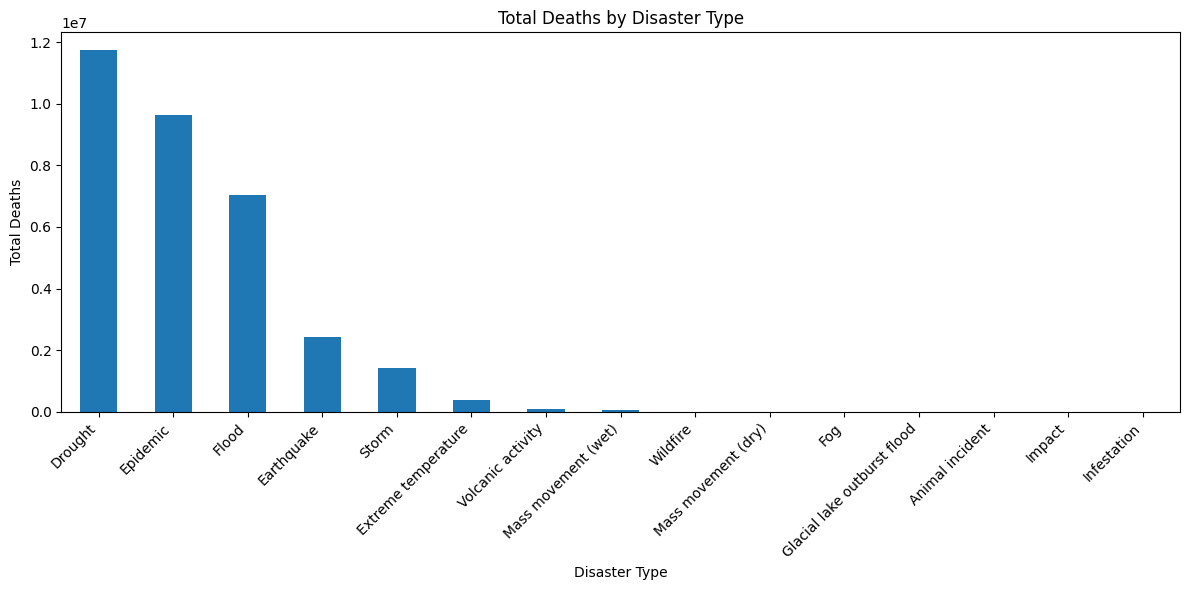

In [23]:

type_deaths = eda_df.groupby("Disaster_Type")["Total_Deaths"].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
type_deaths.plot(kind="bar")
plt.title("Total Deaths by Disaster Type")
plt.xlabel("Disaster Type")
plt.ylabel("Total Deaths")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Compare disaster types by total affected

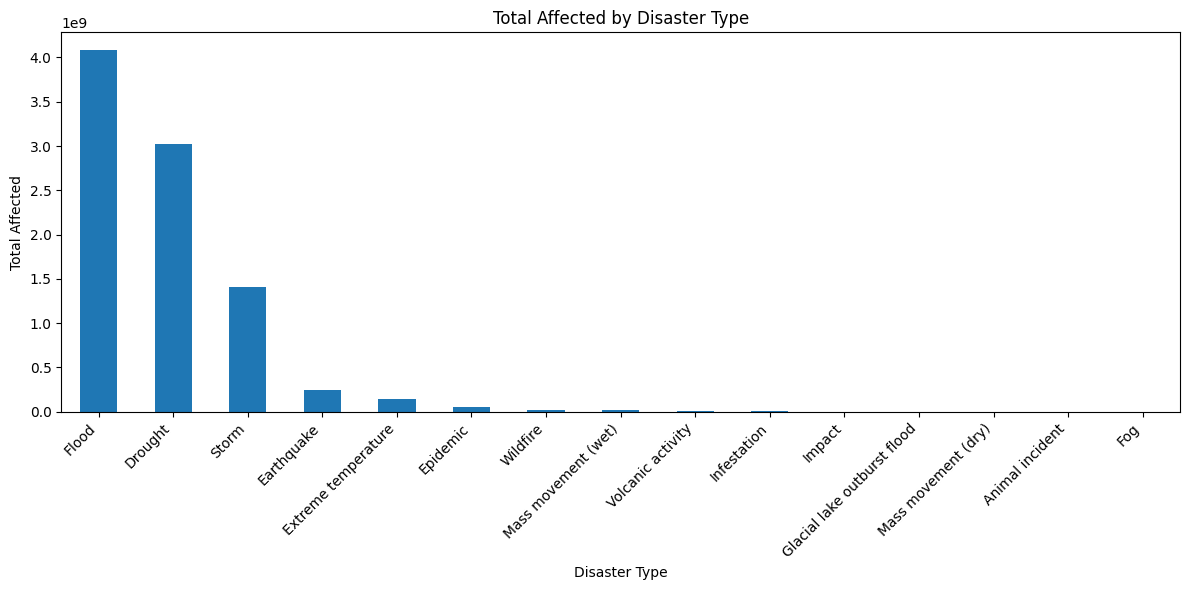

In [24]:

type_affected = eda_df.groupby("Disaster_Type")["Total_Affected"].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
type_affected.plot(kind="bar")
plt.title("Total Affected by Disaster Type")
plt.xlabel("Disaster Type")
plt.ylabel("Total Affected")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Plot major disaster types over time

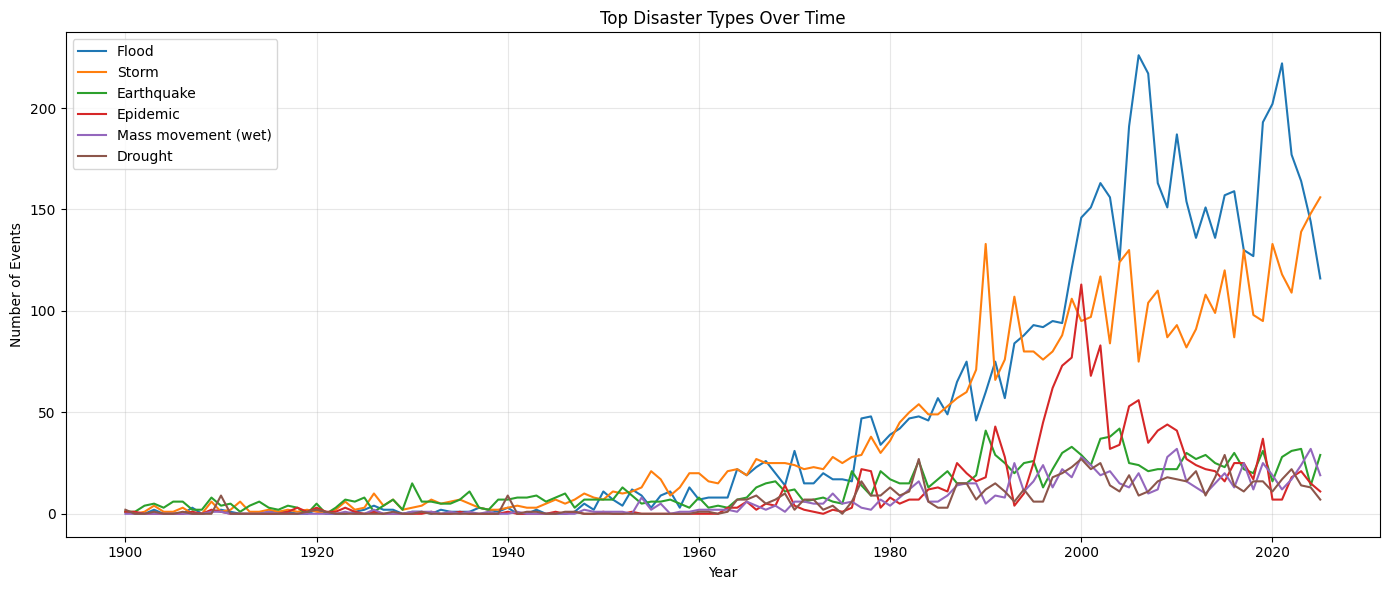

In [53]:
year_type = eda_df[eda_df["Start_Year"] < 2026].groupby(["Start_Year", "Disaster_Type"]).size().unstack(fill_value=0)
top_types = eda_df[eda_df["Start_Year"] < 2026]["Disaster_Type"].value_counts().head(6).index
year_type_top = year_type[top_types]

plt.figure(figsize=(14, 6))
for col in year_type_top.columns:
    plt.plot(year_type_top.index, year_type_top[col], label=col)

plt.title("Top Disaster Types Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Events")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Country-level aggregation

In [26]:

country_summary = eda_df.groupby("Country").agg({
    "DisNo": "count",
    "Total_Deaths": "sum",
    "Total_Affected": "sum",
    "Total_Damage_('000_US$)": "sum"
}).rename(columns={
    "DisNo": "num_events"
}).sort_values("num_events", ascending=False)

country_summary.head(20)


,num_events,Total_Deaths,Total_Affected,Total_Damage_('000_US$)
Country,,,,
United States of America,1211,47199.0,1.176163e+08,1.804873e+09
China,1039,12525973.0,3.336131e+09,6.818056e+08
India,804,9147294.0,2.519975e+09,1.505149e+08
Philippines,730,74448.0,3.306951e+08,3.204462e+07
Indonesia,660,244762.0,6.312675e+07,3.890724e+07
Japan,403,242692.0,2.433205e+07,5.628386e+08
Bangladesh,372,2994455.0,5.246125e+08,2.293736e+07
Mexico,313,25709.0,2.202860e+07,7.024958e+07
Brazil,301,14254.0,1.213062e+08,5.714458e+07


# Top countries by total deaths

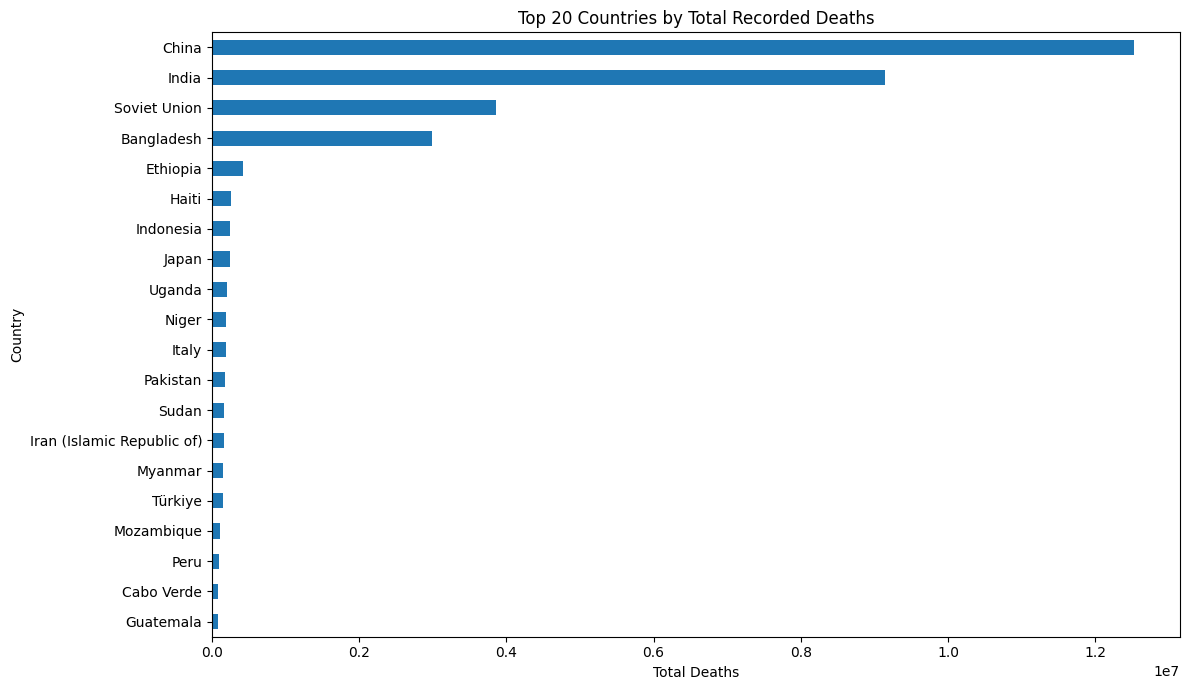

In [27]:

top_country_deaths = country_summary.sort_values("Total_Deaths", ascending=False).head(20)

plt.figure(figsize=(12, 7))
top_country_deaths["Total_Deaths"].sort_values().plot(kind="barh")
plt.title("Top 20 Countries by Total Recorded Deaths")
plt.xlabel("Total Deaths")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


# Top countries by total affected

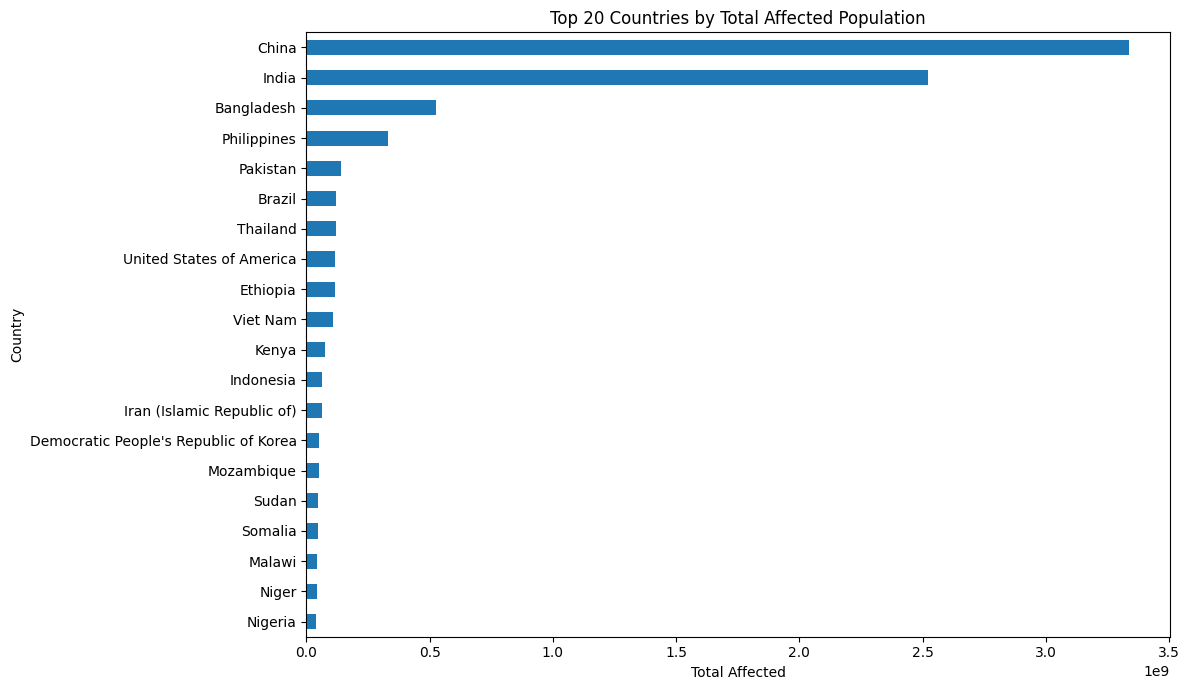

In [28]:

top_country_affected = country_summary.sort_values("Total_Affected", ascending=False).head(20)

plt.figure(figsize=(12, 7))
top_country_affected["Total_Affected"].sort_values().plot(kind="barh")
plt.title("Top 20 Countries by Total Affected Population")
plt.xlabel("Total Affected")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


In [29]:
# Aggregate number of disasters per country
country_disasters = (
    eda_df.groupby(["ISO", "Country"])
    .size()
    .reset_index(name="num_disasters")
)

# Remove rows with missing ISO codes
country_disasters = country_disasters.dropna(subset=["ISO"]).copy()

# Create log-scale version
country_disasters["log_num_disasters"] = np.log1p(country_disasters["num_disasters"])

# Regular scale map
fig = px.choropleth(
    country_disasters,
    locations="ISO",
    color="num_disasters",
    hover_name="Country",
    hover_data={"num_disasters": True, "log_num_disasters": False},
    color_continuous_scale="Reds",
    title="Number of Recorded Disasters by Country",
    labels={"num_disasters": "Number of disasters"}
)

fig.update_layout(
    width=1100,
    height=600,
    margin=dict(l=20, r=20, t=60, b=20)
)

fig.show()

# Log scale map
fig_log = px.choropleth(
    country_disasters,
    locations="ISO",
    color="log_num_disasters",
    hover_name="Country",
    hover_data={"num_disasters": True, "log_num_disasters": False},
    color_continuous_scale="Reds",
    title="Number of Recorded Disasters by Country (Log Scale)",
    labels={"log_num_disasters": "log(1 + disasters)"}
)

fig_log.update_layout(
    width=1100,
    height=600,
    margin=dict(l=20, r=20, t=60, b=20)
)

fig_log.show()